# Introduction to convolutional neural networks and computer vision with TensorFlow and Keras
# https://www.tensorflow.org/tutorials/images/cnn

Computer Vision is the practice of writing algorithms which can discover patterns in visual data. It is a subfield of Artificial Intelligence (AI) and Machine Learning (ML) which focuses on enabling computers to see, identify and process images in a way similar to humans. Convolutional Neural Networks (CNNs) are a class of deep learning models that have proven highly effective for image classification tasks.

## get the data

The image we're working wisth are from the Food-101 dataset. It contains 101 different food categories with 101,000 images. You can find the full dataset on [Kaggle](https://www.kaggle.com/dansbecker/food-101). However we've modified it to only use two classes (pizza and steak) using the image data modification notebook: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

**Note** We start with a smaller dataset so we can experiment quickly. Later on we'll see how to scale this up to larger datasets.

```python
# Download the data (you can also download it manually from Kaggle if you want to see the full dataset)

In [1]:
# import zipfile
# import urllib.request

# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
# zip_path = "pizza_steak.zip"
# urllib.request.urlretrieve(url, zip_path)

# # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()


## Inspect the data (become one with it)

A very crucial step at the beginning of any machine learning project is to become one with the data. This means understanding the data, its structure, and its characteristics. This step is crucial because it helps in making informed decisions about data preprocessing, model selection, and evaluation metrics.

```python

In [1]:
%ls pizza_steak


 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak

05/11/2025  18:48    <DIR>          .
26/12/2025  12:37    <DIR>          ..
05/11/2025  18:48    <DIR>          test
05/11/2025  18:48    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  1,416,952,717,312 bytes free


In [2]:
!dir pizza_steak\train\


 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak\train

05/11/2025  18:48    <DIR>          .
05/11/2025  18:48    <DIR>          ..
05/11/2025  18:48    <DIR>          pizza
05/11/2025  18:48    <DIR>          steak
               0 File(s)              0 bytes
               4 Dir(s)  1,416,952,717,312 bytes free


In [3]:
!dir pizza_steak\train\pizza

 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak\train\pizza

05/11/2025  18:48    <DIR>          .
05/11/2025  18:48    <DIR>          ..
05/11/2025  18:49            45,555 1008104.jpg
05/11/2025  18:49            55,042 1008144.jpg
05/11/2025  18:49            48,090 1008844.jpg
05/11/2025  18:49            44,492 1008941.jpg
05/11/2025  18:49           118,923 1011404.jpg
05/11/2025  18:49            52,687 102037.jpg
05/11/2025  18:49            47,401 1026922.jpg
05/11/2025  18:49            76,126 1029698.jpg
05/11/2025  18:49            57,669 1033251.jpg
05/11/2025  18:49            64,285 1035854.jpg
05/11/2025  18:49            35,744 1038357.jpg
05/11/2025  18:49            51,637 1040878.jpg
05/11/2025  18:49            48,281 1044524.jpg
05/11/2025  18:49            64,412 1044789.jpg
05/11/2025  18:49            41,408 1047561.jpg
05/11/2025  18:49            38,317 1048649.jpg
05/11/2025  18:49        

In [4]:
import os as os
# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


In [5]:
!dir /a pizza_steak


 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak

05/11/2025  18:48    <DIR>          .
26/12/2025  12:37    <DIR>          ..
05/11/2025  18:48    <DIR>          test
05/11/2025  18:48    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  1,416,952,713,216 bytes free


In [6]:
# another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualise our images, first lets get the class names programmatically

In [7]:
# get the class names programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Create a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [8]:
# lets visualize our images

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import random

def view_random_image(target_dir, target_class):
    #Set up the target directory (we'll view images from here)
    target_folder = target_dir+target_class
    #Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1) # list of random images
    print(random_image)

    #read the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");
 # show the shape of the image
    print(f"Image type: {type(img)}")
    print(f"Image shape: {img.shape}")
    print(f"Image min value: {np.min(img)}")
    print(f"Image max value: {np.max(img)}")

    return img

['2924941.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 508, 3)
Image min value: 0
Image max value: 255


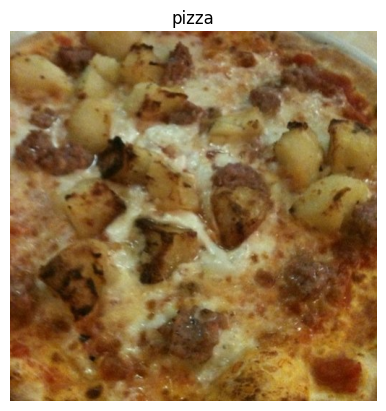

In [9]:
#View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/", target_class="pizza")

In [10]:
img

array([[[179, 180, 148],
        [184, 185, 153],
        [178, 179, 148],
        ...,
        [188, 180, 143],
        [189, 181, 144],
        [190, 182, 145]],

       [[173, 174, 142],
        [182, 183, 151],
        [180, 181, 150],
        ...,
        [187, 179, 142],
        [188, 180, 143],
        [188, 180, 143]],

       [[172, 173, 142],
        [183, 184, 153],
        [183, 186, 157],
        ...,
        [187, 179, 143],
        [187, 179, 143],
        [186, 178, 142]],

       ...,

       [[ 78,  44,  19],
        [ 84,  50,  23],
        [ 86,  51,  23],
        ...,
        [132,  96,  46],
        [131,  95,  43],
        [127,  91,  39]],

       [[ 80,  48,  25],
        [ 84,  52,  27],
        [ 83,  49,  21],
        ...,
        [130,  94,  44],
        [129,  93,  41],
        [124,  88,  36]],

       [[ 74,  42,  19],
        [ 81,  49,  24],
        [ 82,  48,  21],
        ...,
        [134,  98,  48],
        [132,  96,  44],
        [126,  90,  38]]

In [11]:
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 508, 3), dtype=uint8, numpy=
array([[[179, 180, 148],
        [184, 185, 153],
        [178, 179, 148],
        ...,
        [188, 180, 143],
        [189, 181, 144],
        [190, 182, 145]],

       [[173, 174, 142],
        [182, 183, 151],
        [180, 181, 150],
        ...,
        [187, 179, 142],
        [188, 180, 143],
        [188, 180, 143]],

       [[172, 173, 142],
        [183, 184, 153],
        [183, 186, 157],
        ...,
        [187, 179, 143],
        [187, 179, 143],
        [186, 178, 142]],

       ...,

       [[ 78,  44,  19],
        [ 84,  50,  23],
        [ 86,  51,  23],
        ...,
        [132,  96,  46],
        [131,  95,  43],
        [127,  91,  39]],

       [[ 80,  48,  25],
        [ 84,  52,  27],
        [ 83,  49,  21],
        ...,
        [130,  94,  44],
        [129,  93,  41],
        [124,  88,  36]],

       [[ 74,  42,  19],
        [ 81,  49,  24],
        [ 82,  48,  21],
        ...,
        [134,  98,  4

In [12]:
# View image shape
img.shape  # should be (height, width, color_channels)

(512, 508, 3)

In [13]:
# get all the pixel values between 0 and 1
img = img / 255.0 #normalization or scaling
img

array([[[0.70196078, 0.70588235, 0.58039216],
        [0.72156863, 0.7254902 , 0.6       ],
        [0.69803922, 0.70196078, 0.58039216],
        ...,
        [0.7372549 , 0.70588235, 0.56078431],
        [0.74117647, 0.70980392, 0.56470588],
        [0.74509804, 0.71372549, 0.56862745]],

       [[0.67843137, 0.68235294, 0.55686275],
        [0.71372549, 0.71764706, 0.59215686],
        [0.70588235, 0.70980392, 0.58823529],
        ...,
        [0.73333333, 0.70196078, 0.55686275],
        [0.7372549 , 0.70588235, 0.56078431],
        [0.7372549 , 0.70588235, 0.56078431]],

       [[0.6745098 , 0.67843137, 0.55686275],
        [0.71764706, 0.72156863, 0.6       ],
        [0.71764706, 0.72941176, 0.61568627],
        ...,
        [0.73333333, 0.70196078, 0.56078431],
        [0.73333333, 0.70196078, 0.56078431],
        [0.72941176, 0.69803922, 0.55686275]],

       ...,

       [[0.30588235, 0.17254902, 0.0745098 ],
        [0.32941176, 0.19607843, 0.09019608],
        [0.3372549 , 0

"Note: As we've discussed before, many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to scale (also referred to as normalize) their pixel values by dividing the image arrays by 255. (since 255 is the maximum pixel value)."

## An end-to-end example

Lets build a convolutional neural network to find patterns in our images, more specifically we need a way to do:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNNN to our training data


In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32, # number of images to process at a time 
                                               target_size=(224, 224), # convert all images to be 224 x 224
                                               class_mode="binary", # type of problem we're working on
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

# Create a CNN model (same as Tiny VGG - https://poloclub.github.io/cnn-explainer/)
model_1 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=10, 
                         kernel_size=3, # can also be (3, 3)
                         activation="relu", 
                         input_shape=(224, 224, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.6993 - loss: 0.5649 - val_accuracy: 0.8200 - val_loss: 0.3770
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7987 - loss: 0.4520 - val_accuracy: 0.8480 - val_loss: 0.3443
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8200 - loss: 0.4155 - val_accuracy: 0.8480 - val_loss: 0.3741
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8453 - loss: 0.3747 - val_accuracy: 0.7720 - val_loss: 0.4696
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8647 - loss: 0.3414 - val_accuracy: 0.8520 - val_loss: 0.3299


In [23]:
from multiprocessing import pool
from warnings import filters
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Set the seed
tf.random.set_seed(42)

#Preprocess the data (get all of the pixels between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

#Setup paths to our data directories
train_dir  = "C:\\Project_1\\Tensorflow-1\\pizza_steak\\train"
test_dir = "C:\\Project_1\\Tensorflow-1\\pizza_steak\\test"

#Import data from the directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory = 
    train_dir,
    batch_size = 32,
    target_size = (224, 224),
    class_mode = "binary",
    seed = 42)

valid_data = valid_datagen.flow_from_directory(directory = 
    test_dir,
    batch_size = 32,
    target_size = (224, 224),
    class_mode = "binary",
    seed = 42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters = 10, kernel_size = (3, 3), activation = "relu", input_shape = (224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.MaxPool2D(pool_size = 2, padding= "valid"),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

#Compile our CNN
model_1.compile(loss = "binary_crossentropy", 
                optimizer = "adam", 
                metrics = ["accuracy"])
#Fit our model
history_1 = model_1.fit(train_data, 
                        epochs = 5, 
                        steps_per_epoch = len(train_data), 
                        validation_data = (valid_data),
                        validation_steps = len(valid_data))
                        

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6627 - loss: 0.6143 - val_accuracy: 0.7260 - val_loss: 0.4986
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8040 - loss: 0.4419 - val_accuracy: 0.7900 - val_loss: 0.4271
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8367 - loss: 0.3707 - val_accuracy: 0.8720 - val_loss: 0.3063
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8427 - loss: 0.3603 - val_accuracy: 0.8000 - val_loss: 0.4089
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8640 - loss: 0.3173 - val_accuracy: 0.7880 - val_loss: 0.4601


In [24]:
# get a model summary
model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

### Using the same model as before

Lets replicate the model we've built in a previous section to see if it works with our image data.
the model we're building is from the tensorflow playground: [https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.35726&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false]


In [27]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the tensoflow playground model
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compile the model
model_2.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

#Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5


c:\Project_1\ml_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5120 - loss: 0.7643 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


In [28]:
# get a model summary
model_2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

Despite having 20x more parameters than our CNN model (model_1), model_2 performs terribly... let's try

In [30]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the tensoflow playground model
model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compile the model
model_3.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

#Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5933 - loss: 4.0384 - val_accuracy: 0.6240 - val_loss: 1.6849
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.6767 - loss: 1.0142 - val_accuracy: 0.7440 - val_loss: 0.8427
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7433 - loss: 0.6015 - val_accuracy: 0.6660 - val_loss: 0.7879
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7480 - loss: 0.5496 - val_accuracy: 0.6760 - val_loss: 0.6579
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7567 - loss: 0.5612 - val_accuracy: 0.7800 - val_loss: 0.4654


In [31]:
# get a summary of model_3
model_3.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

Note: you can think of trainable parameters as patterns a model learns from data. intuitively, the more trainable parameters a model has, the more patterns it can learn. intuitively, this should lead to better performance, however, too many trainable parameters can lead to overfitting. Intuitively, you might think more is better. And in lots of cases, it is. But in this case, the differences here is the two different styles of model we're using. Where a series of a dense layers has a number of different learnable parameters connected to each other and hence a higher number of possible learnable patterns, a ***convolutional neural network seeks to sort out and learn the most important patterns in an image***. So even though these are less learnable paramenters in our convolutional neural network, these are often more helpful in dechiphering between different ***features*** in an image. 

## Binary classification evaluation metrics - lets break it down

1. Become one with the data (visualize, visualize, vizualize)
2. Preprocess the data (prepared it for our model, the main step here was scaling / normalizing)
3. Created a model( start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)


## 1. Become one with the data

['2222018.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 512, 3)
Image min value: 0
Image max value: 255
['3822139.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 512, 3)
Image min value: 0
Image max value: 255


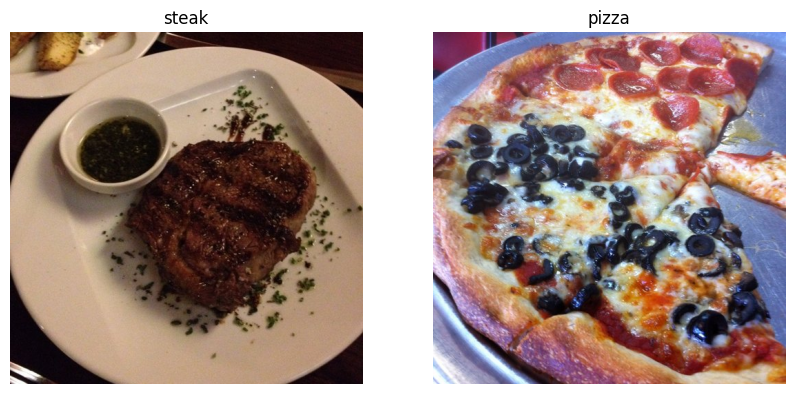

In [35]:
# Visualize data
plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
steak_img = view_random_image(target_dir="pizza_steak/train/", target_class="steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image(target_dir="pizza_steak/train/", target_class="pizza")
